<div style="display: flex; align-items: center;">
    <div style="display: flex; flex-direction: column; align-items: center;">
        <h1 style="text-align: right;">Centro de Investigación en Matemáticas, A.C.</h1>
        <h2 style="text-align: right;">Modelos Generativos Profundos</h2>
        <h2 style="text-align: right;">Jose Miguel Saavedra Aguilar</h2>
        <h3 style="text-align: right;">Project 2. Part 2: Butterflies</h3>
    </div>
    <img src="https://www.cimat.mx/~adolfofest/images/LOGOTIPO_SIN_FONDO-02.png" alt="CIMAT Logo" width="200" style="float: left;">
</div>


---

## MNIST
On this notebook, we will implement an LSGM model to generate images from the Smithsonian butterflies dataset.

In [ ]:
# Install required libraries for this notebook
!pip install torchinfo torchmetrics datasets lpips

In [ ]:
# Import core libraries for deep learning, data handling, and visualization.
import math, os, gc, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from torchinfo import summary  # Model summary utility (optional, not required for training)
from torchmetrics import MeanMetric  # For tracking metrics during training
from tqdm import tqdm  # Progress bar for loops
import numpy as np
from datasets import load_dataset  # HuggingFace datasets
from PIL import Image  # Image processing
import lpips  # Learned perceptual image patch similarity

In [ ]:
# Select the best available device for computation (GPU, TPU, or CPU).
if torch.cuda.is_available():
    # Use CUDA GPU if available
    device = torch.device("cuda")
elif 'TPU_ACCELERATOR_TYPE' in os.environ or 'COLAB_TPU_1vm' in os.environ:
    # Use TPU if running in a TPU-enabled environment (e.g., Colab)
    import torch_xla
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
else:
    # Default to CPU if no accelerator is found
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Load the Smithsonian butterflies dataset from HuggingFace and prepare it for PyTorch.
class ButterflyDataset(Dataset):
    def __init__(self, split="train", image_size=128):
        # Load the dataset split (e.g., 'train')
        self.ds = load_dataset("huggan/smithsonian_butterflies_subset", split=split)
        # Define image transformations: resize and convert to tensor
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        # Return the number of images in the dataset
        return len(self.ds)

    def __getitem__(self, idx):
        # Get the image at the given index
        img = self.ds[idx]["image"]
        # Convert to PIL Image if needed
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        # Apply transformations
        img = self.transform(img)
        return img

# Set image size and number of channels
image_size = 128
channels = 3
# Create the training dataset and loader
train_dataset = ButterflyDataset(split="train", image_size=image_size)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Repo card metadata block was not found. Setting CardData to empty.


First, we use a convolutional VAE to encode and decode the images.

In [ ]:
# Reparameterization trick: sample latent z from N(mu, sigma^2) using mu and log_var.
def reparameterize(mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
    std = torch.exp(0.5 * log_var)  # Compute standard deviation from log-variance
    eps = torch.randn_like(std)     # Sample standard normal noise
    return mu + eps * std          # Return sampled latent variable

# Convolutional layer with GroupNorm and SiLU activation, used throughout the VAE.
class ConvGN(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel_size=3, stride=1, padding=1, groups=8):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding)
        self.gn = nn.GroupNorm(num_groups=min(groups, out_ch), num_channels=out_ch)
        self.act = nn.SiLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.gn(self.conv(x)))

# Residual block with two ConvGN layers and dropout, used in encoder/decoder.
class ResidualConvBlock(nn.Module):
    def __init__(self, channels: int, groups: int = 8, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            ConvGN(channels, channels, kernel_size=3, padding=1, groups=groups),
            nn.Dropout2d(dropout),
            ConvGN(channels, channels, kernel_size=3, padding=1, groups=groups),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.net(x)  # Residual connection

In [ ]:
# Encoder network for the VAE: encodes input images into latent mean and log-variance maps.
class Encoder(nn.Module):
    def __init__(self, input_channels: int, z_channels: int, base_channels: int = 64,
                 channel_multipliers: tuple = (1, 2, 2, 4),  # Controls downsampling at each stage
                 num_res_blocks: int = 2):
        super().__init__()
        # Initial convolution to project input to base_channels
        self.input_conv = ConvGN(input_channels, base_channels, kernel_size=3, padding=1, stride=1)

        channels = [base_channels]
        in_ch = base_channels
        self.down_blocks = nn.ModuleList()
        for i, mult in enumerate(channel_multipliers):
            out_ch = base_channels * mult
            # Add a sequence of residual blocks at each resolution
            for _ in range(num_res_blocks):
                self.down_blocks.append(ResidualConvBlock(in_ch, groups=min(8, in_ch)))
            # Downsample spatially (except after last block)
            if i < len(channel_multipliers) - 1:
                self.down_blocks.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1))
                in_ch = out_ch
                channels.append(in_ch)
            else:
                # Final conv to produce both mu and logvar (no downsampling at last stage)
                self.down_blocks.append(ConvGN(in_ch, 2 * z_channels, kernel_size=3, padding=1))
                in_ch = 2 * z_channels

        self.final_channels = 2 * z_channels  # Output channels: mu + logvar

    def forward(self, x):
        h = self.input_conv(x)
        for block in self.down_blocks:
            if isinstance(block, nn.Conv2d) and block.stride == (2, 2):
                h = block(h)
            else:
                h = block(h)
        # Output is [B, 2*z_channels, H, W]: split into mu and logvar
        mu, log_var = torch.chunk(h, 2, dim=1)
        return mu, log_var


In [ ]:
# Decoder network for the VAE: reconstructs images from latent variables.
class Decoder(nn.Module):
    def __init__(self, z_channels: int, out_channels: int, base_channels: int = 64,
                 channel_multipliers: tuple = (4, 2, 2, 1),  # Reverse of encoder's multipliers
                 num_res_blocks: int = 2):
        super().__init__()
        in_ch = z_channels
        # Initial convolution to project latent z to feature space
        self.input_conv = ConvGN(in_ch, base_channels * channel_multipliers[0], kernel_size=3, padding=1)

        self.up_blocks = nn.ModuleList()
        in_ch = base_channels * channel_multipliers[0]

        for i, mult in enumerate(channel_multipliers):
            out_ch = base_channels * mult
            # Add a sequence of residual blocks at each resolution (extra at start for symmetry)
            for _ in range(num_res_blocks + (1 if i == 0 else 0)):
                self.up_blocks.append(ResidualConvBlock(in_ch, groups=min(8, in_ch)))
            # Upsample spatially (except after last block)
            if i < len(channel_multipliers) - 1:
                next_mult = channel_multipliers[i + 1]
                next_ch = base_channels * next_mult
                self.up_blocks.append(nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='nearest'),
                    ConvGN(in_ch, next_ch, kernel_size=3, padding=1)
                ))
                in_ch = next_ch

        # Final normalization, convolution, and sigmoid to produce output image
        self.final = nn.Sequential(
            nn.GroupNorm(num_groups=min(8, in_ch), num_channels=in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_channels, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        h = self.input_conv(z)
        for block in self.up_blocks:
            h = block(h)
        return self.final(h)


In [ ]:
# Variational Autoencoder (VAE) combining the Encoder and Decoder networks.
class VAE(nn.Module):
    def __init__(self, input_channels: int = 3, z_channels: int = 4, base_channels: int = 64,
                 channel_multipliers: tuple = (1, 2, 2, 4), num_res_blocks: int = 2):
        super().__init__()
        # Encoder: maps input images to latent mean and log-variance
        self.encoder = Encoder(
            input_channels=input_channels,
            z_channels=z_channels,
            base_channels=base_channels,
            channel_multipliers=channel_multipliers,
            num_res_blocks=num_res_blocks
        )
        # Decoder: reconstructs images from latent variables
        self.decoder = Decoder(
            z_channels=z_channels,
            out_channels=input_channels,
            base_channels=base_channels,
            channel_multipliers=tuple(reversed(channel_multipliers)),
            num_res_blocks=num_res_blocks
        )
        self.z_channels = z_channels

    def forward(self, x):
        # Encode input to latent mean and log-variance
        mu, log_var = self.encoder(x)
        # Sample latent variable using reparameterization trick
        z = reparameterize(mu, log_var)
        # Decode latent variable to reconstruct image
        x_recon = self.decoder(z)
        return x_recon, mu, log_var

    def encode(self, x):
        # Return latent mean and log-variance for input
        mu, log_var = self.encoder(x)
        return mu, log_var

    def decode(self, z):
        # Decode latent variable to image
        return self.decoder(z)

For the loss function, we use the ELBO, but we consider different reconstruction losses. One of them is the mean squared error (MSE) loss, as well as the binary cross-entropy (BCE) loss and the LPIPS loss.

In [ ]:
# Loss functions for VAE training, including KL divergence and flexible reconstruction losses.
def kl_divergence(mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
    # Compute KL divergence between N(mu, sigma^2) and N(0, 1) for each element
    return -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

# Perceptual loss function (LPIPS) for image similarity, using a pretrained VGG network
lpips_loss_fn = lpips.LPIPS(net='vgg').to(device).eval()

def vae_loss(x: torch.Tensor, x_recon: torch.Tensor, mu: torch.Tensor, log_var: torch.Tensor,
             recon_loss: str = 'mse', reduction: str = 'sum', beta: float = 1.0) -> torch.Tensor:
    # Compute reconstruction loss based on selected metric
    if recon_loss == 'mse':
        recon = F.mse_loss(x_recon, x, reduction=reduction)
    elif recon_loss == 'bce':
        recon = F.binary_cross_entropy(x_recon, x, reduction=reduction)
    elif recon_loss == 'lpips':
        # LPIPS expects images in [-1,1], so rescale if needed
        x_lp = (x * 2) - 1 if x.min() >= 0 else x
        x_recon_lp = (x_recon * 2) - 1 if x_recon.min() >= 0 else x_recon
        with torch.no_grad():
            recon = lpips_loss_fn(x_lp, x_recon_lp).mean()
    else:
        raise ValueError('recon_loss must be "mse", "bce", or "lpips"')
    # Compute KL divergence regularization term
    kl = kl_divergence(mu, log_var)
    # Return total VAE loss: reconstruction + weighted KL
    return recon + beta * kl


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth


In [ ]:
# Set hyperparameters and model sizes for the butterfly dataset experiments.
input_channels = channels  # Number of input image channels (e.g., 3 for RGB)
z_channels = 16           # Number of latent channels (higher = more capacity)
base_channels = 128       # Base number of channels for encoder/decoder
channel_multipliers = (1, 2, 4, 8)  # Channel scaling at each resolution
epochs_vae = 20           # Number of training epochs for the VAE
lr_vae = 1e-3             # Learning rate for VAE optimizer

In [ ]:
# Initialize and prepare the VAE model for training.
print("=== Stage 1: Training VAE ===")
vae = VAE(
    input_channels=input_channels,  # Number of input channels (e.g., 3 for RGB)
    z_channels=z_channels,          # Latent space dimensionality
    base_channels=base_channels,    # Base number of channels for model layers
    channel_multipliers=channel_multipliers,  # Channel scaling at each resolution
    num_res_blocks=2                # Number of residual blocks per resolution
).to(device)
vae_optimizer = torch.optim.Adam(vae.parameters(), lr=lr_vae)  # Adam optimizer for VAE
vae.train()  # Set VAE to training mode

=== Stage 1: Training VAE ===


VAE(
  (encoder): Encoder(
    (input_conv): ConvGN(
      (conv): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (gn): GroupNorm(8, 128, eps=1e-05, affine=True)
      (act): SiLU()
    )
    (down_blocks): ModuleList(
      (0-1): 2 x ResidualConvBlock(
        (net): Sequential(
          (0): ConvGN(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (gn): GroupNorm(8, 128, eps=1e-05, affine=True)
            (act): SiLU()
          )
          (1): Dropout2d(p=0.1, inplace=False)
          (2): ConvGN(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (gn): GroupNorm(8, 128, eps=1e-05, affine=True)
            (act): SiLU()
          )
        )
      )
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3-4): 2 x ResidualConvBlock(
        (net): Sequential(
          (0): ConvGN(
            (conv): Conv2d(128, 128, kernel_s

In [ ]:
# Standard training loop for the VAE model.
vae.train()
for epoch in range(epochs_vae):
    torch.cuda.empty_cache()  # Clear GPU memory at the start of each epoch
    total_loss = 0.0
    # Iterate over all batches in the training set
    for batch_idx, x in tqdm(enumerate(train_loader), total=len(train_loader)):
        x = x.to(device)  # Move batch to the selected device
        vae_optimizer.zero_grad()  # Reset gradients
        x_recon, mu, log_var = vae(x)  # Forward pass through VAE
        loss = vae_loss(x, x_recon, mu, log_var, recon_loss="mse")  # Compute VAE loss (MSE reconstruction)
        loss.backward()  # Backpropagation
        vae_optimizer.step()  # Update model parameters
        total_loss += loss.item()  # Accumulate total loss
    avg_loss = total_loss / len(train_loader.dataset)  # Average loss per sample
    print(f"VAE Epoch {epoch+1}/{epochs_vae} | Avg ELBO per sample: {avg_loss:.4f}")

100%|██████████| 16/16 [17:37<00:00, 66.07s/it]


VAE Epoch 1/20 | Avg ELBO per sample: 1431.7066


100%|██████████| 16/16 [18:23<00:00, 68.95s/it]


VAE Epoch 2/20 | Avg ELBO per sample: 1426.5106


100%|██████████| 16/16 [18:24<00:00, 69.04s/it]


...

100%|██████████| 16/16 [17:46<00:00, 66.66s/it]


VAE Epoch 12/20 | Avg ELBO per sample: 1431.8324


100%|██████████| 16/16 [17:45<00:00, 66.62s/it]


VAE Epoch 13/20 | Avg ELBO per sample: 1427.5083


 44%|████▍     | 7/16 [08:02<10:16, 68.46s/it]

In [ ]:
# Save the trained VAE model weights to a file for later reuse or evaluation.
torch.save(vae.state_dict(), "vae_butterflies.pth")
print("VAE trained and saved.")

In [ ]:
# Reload the trained VAE model weights from file, or initialize from scratch if loading fails.
vae = VAE(
    input_channels=input_channels,
    z_channels=z_channels,
    base_channels=base_channels,
    channel_multipliers=channel_multipliers,
    num_res_blocks=2
).to(device)
try:
    state = torch.load("vae_butterflies.pth", map_location=device)  # Load weights from file
    vae.load_state_dict(state)
    print("VAE loaded from file.")
except Exception as e:
    print("Error loading VAE from file:", e)
    print("Train VAE from scratch.")

VAE loaded from file.


We will use the U-Net architecture provided in class for the score network. It matches the dimensions of the latent space of the VAE.

In [ ]:
# DDPM/DDIM utilities for latent diffusion processes.
def make_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    # Create a linear schedule for beta values over T diffusion steps
    return torch.linspace(beta_start, beta_end, T)

T = 1000  # Number of diffusion steps
betas = make_beta_schedule(T).to(device)  # Linear beta schedule
alphas = 1. - betas  # Alpha values for each step
alphas_cumprod = torch.cumprod(alphas, dim=0)  # Cumulative product of alphas
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)  # Used for forward process
sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)  # Used for noise scaling

def extract(a, t, x_shape):
    # Helper to extract t-indexed values for each batch element, reshaped to match input shape
    b = t.shape[0]
    out = a.gather(-1, t).float()
    return out.reshape(b, *((1,) * (len(x_shape) - 1)))

In [ ]:
# Utility function to extract values from a tensor at specific indices, reshaped for broadcasting.
def get_from_idx(element: torch.Tensor, idx: torch.Tensor):
    ele = element.gather(-1, idx)
    return ele.reshape(-1, 1, 1, 1)

# ForwardSampler implements the forward diffusion process for DDPM/score-based models.
class ForwardSampler(nn.Module):
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=2e-2):
        super().__init__()
        self.timesteps = timesteps
        # Create a linear schedule for beta values over the diffusion steps
        beta = torch.linspace(beta_start, beta_end, self.timesteps, dtype=torch.float32)
        self.register_buffer("beta", beta)
        self.register_buffer("alpha", 1 - self.beta)
        self.register_buffer("alpha_bar", torch.cumprod(self.alpha, dim=0))
        self.register_buffer("sqrt_alpha_bar", torch.sqrt(self.alpha_bar))
        self.register_buffer("one_by_sqrt_alpha", 1. / torch.sqrt(self.alpha))
        self.register_buffer("sqrt_one_minus_alpha_bar", torch.sqrt(1 - self.alpha_bar))

    # Directly sample q(x_t|x_0) to generate x_t from x_0 in a single step.
    # This avoids iterating through all individual diffusion steps.
    def forward(self, x0: torch.Tensor, timesteps: torch.Tensor):
        # Generate standard normal noise
        epsilon = torch.randn_like(x0)
        # Get the mean and standard deviation for the queried timesteps
        mean    = get_from_idx(self.sqrt_alpha_bar, timesteps) * x0      # Mean
        std_dev = get_from_idx(self.sqrt_one_minus_alpha_bar, timesteps) # Standard deviation
        # Sample is mean plus scaled noise
        sample  = mean + std_dev * epsilon
        return sample, epsilon

In [ ]:
# DDPM class extends ForwardSampler to implement the reverse diffusion process (one backward step).
class DDPM(ForwardSampler):
    # Implements a single reverse diffusion step for DDPM sampling.
    def step_backward(self, predicted_noise:torch.Tensor, xnoise:torch.Tensor, timestep: int):
        # Sample noise for stochasticity, except for the final step (t=0) where no noise is added
        z  = torch.randn_like(xnoise) if timestep > 0 else torch.zeros_like(xnoise)
        beta_t                     = self.beta[timestep].reshape(-1, 1, 1, 1)
        one_by_sqrt_alpha_t        = self.one_by_sqrt_alpha[timestep].reshape(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_bar[timestep].reshape(-1, 1, 1, 1)
        # Compute the denoised sample using the DDPM update rule
        xdenoised = (
            one_by_sqrt_alpha_t
            * (xnoise - (beta_t / sqrt_one_minus_alpha_bar_t) * predicted_noise)
            + torch.sqrt(beta_t) * z
        )
        return xdenoised

In [ ]:
# Single training step for the DDPM/score network.
def train_step(batch:torch.Tensor, model:nn.Module, forwardsampler:DDPM):
    # Sample a random timestep for each image in the batch
    t = torch.randint(low=0, high=forwardsampler.timesteps, size=(batch.shape[0],), device=batch.device)
    # Apply the forward diffusion process to obtain noisy images and the true noise
    x_noisy, eps_true = forwardsampler(batch, t)
    with amp.autocast():
        # Predict the noise using the score network (model)
        eps_predicted = model(x_noisy, t)
        # Compute the MSE loss between predicted and true noise
        loss          = F.mse_loss(eps_predicted, eps_true)
    return loss

In [ ]:
# Function to generate samples from the trained diffusion model by reversing the diffusion process.
@torch.inference_mode()
def generate(denoiser_model:nn.Module, backward_sampler:DDPM, size, device):
    # Start from pure Gaussian noise in the latent space
    x_T = torch.randn(size, device=device)
    # Reverse the diffusion process step by step
    for t in tqdm(iterable=reversed(range(0, backward_sampler.timesteps)),
                          dynamic_ncols=False,total=backward_sampler.timesteps,
                          desc="Sampling :: ", position=0):
        # Prepare the current timestep as a tensor for the batch
        t_tensor = torch.as_tensor(t, dtype=torch.long, device=device).reshape(-1).expand(x_T.shape[0])
        # Predict the noise at this step using the denoiser model
        eps_pred = denoiser_model(x_T, t_tensor)
        # Denoise with the sampler and the estimated noise
        x_T = backward_sampler.step_backward(eps_pred, x_T, t)
    return x_T

In [ ]:
# Sinusoidal time embedding for diffusion models and transformers.
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        # Compute the frequency bands for the embedding
        freqs = torch.exp(
            -torch.arange(half, device=t.device) * (math.log(10000) / (half - 1))
        )
        # Calculate the sinusoidal embedding for each timestep
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        return torch.cat([args.sin(), args.cos()], dim=1)


In [ ]:
# Sinusoidal position embedding with MLP expansion for time steps in diffusion models.
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, total_time_steps=1000, time_emb_dims=128, time_emb_dims_exp=512):
        super().__init__()
        self.total_time_steps = total_time_steps
        self.time_emb_dims = time_emb_dims
        self.time_emb_dims_exp = time_emb_dims_exp

        # Precompute the sinusoidal embedding table for all time steps
        half_dim = time_emb_dims // 2
        emb = math.log(10000) / (half_dim - 1 + 1e-8)  # avoid div by zero
        freqs = torch.exp(torch.arange(half_dim, dtype=torch.float32) * -emb)  # [half_dim]
        ts = torch.arange(total_time_steps, dtype=torch.float32).unsqueeze(1)   # [T, 1]
        emb_table = torch.cat([
            torch.sin(ts * freqs),
            torch.cos(ts * freqs)
        ], dim=-1)  # [T, time_emb_dims]

        self.register_buffer("emb_table", emb_table)  # Moves with model to device

        # MLP to expand the embedding dimension
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dims, time_emb_dims_exp),
            nn.SiLU(),
            nn.Linear(time_emb_dims_exp, time_emb_dims_exp),
        )

    def forward(self, time):
        # time: [B], dtype=torch.long, values in [0, total_time_steps)
        emb = self.emb_table[time]  # [B, time_emb_dims]
        return self.time_mlp(emb)   # [B, time_emb_dims_exp]

In [ ]:
# Self-attention block for 2D feature maps, used in U-Net architectures for diffusion models.
class AttentionBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.channels  = channels
        self.group_norm= nn.GroupNorm(num_groups=8,num_channels=channels)
        self.mhsa      = nn.MultiheadAttention(embed_dim=self.channels,num_heads=4,batch_first=True)

    def forward(self, x):
        B, _, H, W = x.shape
        # Normalize and reshape input for multi-head self-attention
        h          = self.group_norm(x)
        h          = h.reshape(B, self.channels, H * W).swapaxes(1, 2)
        h, _       = self.mhsa(h, h, h)
        # Reshape back to original feature map shape and add residual connection
        h          = h.swapaxes(2, 1).view(B, self.channels, H, W)
        return x + h

In [ ]:
# Residual block with time embedding and optional attention, used in U-Net architectures for diffusion models.
class ResnetBlock(nn.Module):
    def __init__(self, *, in_channels, out_channels, dropout_rate=0.1, time_emb_dims=512, apply_attention=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels= out_channels

        self.activation  = nn.SiLU()
        # Group 1: normalization and convolution
        self.normalize_1 = nn.GroupNorm(num_groups=8, num_channels=self.in_channels)
        self.conv_1      = nn.Conv2d(in_channels=self.in_channels, out_channels=self.out_channels, kernel_size=3, stride=1, padding="same")

        # Group 2: time embedding projection
        self.dense_1    = nn.Linear(in_features=time_emb_dims, out_features=self.out_channels)

        # Group 3: normalization, dropout, and convolution
        self.normalize_2= nn.GroupNorm(num_groups=8, num_channels=self.out_channels)
        self.dropout    = nn.Dropout2d(p=dropout_rate)
        self.conv_2     = nn.Conv2d(in_channels=self.out_channels, out_channels=self.out_channels, kernel_size=3, stride=1, padding="same")

        # Match input channels to output channels if needed for residual connection
        if self.in_channels != self.out_channels:
            self.match_input = nn.Conv2d(in_channels=self.in_channels, out_channels=self.out_channels, kernel_size=1, stride=1)
        else:
            self.match_input = nn.Identity()

        # Optional attention block
        if apply_attention:
            self.attention = AttentionBlock(channels=self.out_channels)
        else:
            self.attention = nn.Identity()

    def forward(self, x, t):
        # Group 1: normalization and convolution
        h = self.activation(self.normalize_1(x))
        h = self.conv_1(h)

        # Group 2: add in timestep embedding
        h += self.dense_1(self.activation(t))[:, :, None, None]

        # Group 3: normalization, dropout, and convolution
        h = self.activation(self.normalize_2(h))
        h = self.dropout(h)
        h = self.conv_2(h)

        # Residual connection and optional attention
        h = h + self.match_input(x)
        h = self.attention(h)

        return h

In [ ]:
# Downsampling layer using a strided convolution, reduces spatial resolution by a factor of 2.
class DownSample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.downsample = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3, stride=2, padding=1)
    def forward(self, x, *args):
        return self.downsample(x)

# Upsampling layer using nearest neighbor interpolation followed by a convolution, doubles spatial resolution.
class UpSample(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_channels=in_channels, out_channels=in_channels, kernel_size=3, stride=1, padding=1))
    def forward(self, x, *args):
        return self.upsample(x)

In [ ]:
# U-Net architecture for latent diffusion, adapted from class (Session 26: Flow matching).
class UNet(nn.Module):
    def __init__(
        self,
        input_channels = 128,
        output_channels= 128,
        num_res_blocks = 2,
        base_channels  = 128,
        # Resolutions
        base_channels_multiples=(1, 2, 4, 8),
        apply_attention=(False, False, True, True),
        dropout_rate=0.1,
        time_multiple=4
):
        super().__init__()
        time_emb_dims_exp = base_channels * time_multiple
        # Sinusoidal time embedding for diffusion steps
        self.time_embeddings = SinusoidalPositionEmbeddings(time_emb_dims=base_channels, time_emb_dims_exp=time_emb_dims_exp)
        # Initial convolution to project input to base_channels
        self.first = nn.Conv2d(in_channels=input_channels, out_channels=base_channels, kernel_size=3, stride=1, padding="same")

        num_resolutions = len(base_channels_multiples)

        # Encoder: downsampling path with residual and attention blocks
        self.encoder_blocks = nn.ModuleList()
        curr_channels = [base_channels]
        in_channels = base_channels

        for level in range(num_resolutions):
            out_channels = base_channels * base_channels_multiples[level]

            for _ in range(num_res_blocks):
                block = ResnetBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp,
                    apply_attention=apply_attention[level],
                )
                self.encoder_blocks.append(block)
                in_channels = out_channels
                curr_channels.append(in_channels)
            if level != (num_resolutions - 1):
                self.encoder_blocks.append(DownSample(channels=in_channels))
                curr_channels.append(in_channels)

        # Bottleneck: two residual blocks, one with attention
        self.bottleneck_blocks = nn.ModuleList(
            (
                ResnetBlock(
                    in_channels=in_channels,
                    out_channels=in_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp,
                    apply_attention=True,
                ),
                ResnetBlock(
                    in_channels=in_channels,
                    out_channels=in_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp,
                    apply_attention=False,
                ),
            )
        )

        # Decoder: upsampling path with skip connections
        self.decoder_blocks = nn.ModuleList()

        for level in reversed(range(num_resolutions)):
            out_channels = base_channels * base_channels_multiples[level]

            for _ in range(num_res_blocks + 1):
                encoder_in_channels = curr_channels.pop()
                block = ResnetBlock(
                    in_channels=encoder_in_channels + in_channels,
                    out_channels=out_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp,
                    apply_attention=apply_attention[level],
                )

                in_channels = out_channels
                self.decoder_blocks.append(block)

            if level != 0:
                self.decoder_blocks.append(UpSample(in_channels))

        # Final normalization and convolution to produce output
        self.final = nn.Sequential(
            nn.GroupNorm(num_groups=8, num_channels=in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels=in_channels, out_channels=output_channels, kernel_size=3, stride=1, padding="same"),
        )

    def forward(self, x, t):
        # Compute time embeddings for the batch
        time_emb = self.time_embeddings(t)
        h = self.first(x)
        outs = [h]

        # Encoder: store outputs for skip connections
        for layer in self.encoder_blocks:
            h = layer(h, time_emb)
            outs.append(h)

        # Bottleneck blocks
        for layer in self.bottleneck_blocks:
            h = layer(h, time_emb)

        # Decoder: concatenate skip connections
        for layer in self.decoder_blocks:
            if isinstance(layer, ResnetBlock):
                out = outs.pop()
                if h.shape[2:] != out.shape[2:]:
                    min_h, min_w = min(h.shape[2], out.shape[2]), min(h.shape[3], out.shape[3])
                    h = h[:, :, :min_h, :min_w]
                    out = out[:, :, :min_h, :min_w]
                h = torch.cat([h, out], dim=1)
            h = layer(h, time_emb)
        h = self.final(h)

        return h

In [ ]:
# ----------------------------
# Stage 2: Train the latent DDPM (UNet) score network
print("\n=== Stage 2: Training Latent DDPM Score Model ===")
# Freeze VAE parameters so only the score network is trained
for param in vae.parameters():
    param.requires_grad_(False)
vae.eval()

# The latent shape after encoding images with the VAE
# [B, z_channels, 16, 16] for 128x128 images and 4 downsamples
latent_shape = (z_channels, 16, 16)

# Initialize the U-Net denoiser model for the latent space
denoiser_model = UNet(
    input_channels=z_channels,
    output_channels=z_channels,
    base_channels=128,
    base_channels_multiples=(1, 2, 4, 8),
    apply_attention=(False, False, True, True),
    num_res_blocks=2,
    dropout_rate=0.1,
    time_multiple=4,
    # U-Net matches the latent space dimensions
    ).to(device)

# Optimizer and learning rate scheduler for the score network
optimizer = torch.optim.AdamW(denoiser_model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# MSE loss for score matching
loss_fn = nn.MSELoss()

# Initialize the DDPM forward/reverse diffusion process for latents
diffusionmodel = DDPM(timesteps = 1000)
diffusionmodel.to(device)
# Mixed precision scaler for efficient training on CUDA
scaler = torch.amp.GradScaler('cuda')

ddpm_epochs = 10  # Number of epochs to train the score network


=== Stage 2: Training Latent DDPM Score Model ===


Still using the weights. Note we trained it multiple times on low epochs as the training takes very long.

In [ ]:
# Training: one epoch for latent diffusion
# This function performs a single training epoch for the latent diffusion score network.
def train_one_epoch(model, sampler, loader, optimizer, scaler, vae, device, epoch=1):
    loss_record = MeanMetric().to(device)  # Track average loss for the epoch
    model.train()
    vae.eval()  # VAE is frozen during score network training
    with tqdm(total=len(loader), dynamic_ncols=True) as tq:
        tq.set_description(f"Train :: Epoch: {epoch}")
        for x in loader:
            tq.update(1)
            x = x.to(device)
            with torch.no_grad():
                # Encode images to latent space using VAE encoder
                mu, log_var = vae.encoder(x)
                z = reparameterize(mu, log_var)  # Sample latent z from encoder output
            # Sample random diffusion time step for each sample
            t = torch.randint(0, sampler.timesteps, (z.size(0),), device=device)
            # Forward diffusion: add noise to latent z
            z_t, eps_true = sampler(z, t)

            # Forward pass with DDPM weighting
            with torch.amp.autocast('cuda'):
                eps_pred = model(z_t, t)  # Predict noise with score network
                # Compute per-sample mean squared error
                se = (eps_pred - eps_true).pow(2)                     # [B, C, H, W]
                se_per_sample = se.view(se.size(0), -1).mean(dim=1)  # [B]

                # Get DDPM weighting for each sample
                beta_t = sampler.beta[t].to(z.device)
                alpha_bar_t = sampler.alpha_bar[t].to(z.device)
                w_t = beta_t / (1.0 - alpha_bar_t + 1e-12)

                # Final loss: weighted MSE averaged over batch
                loss = 0.5 * (w_t * se_per_sample).mean()

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            loss_value = loss.detach().item()
            loss_record.update(loss_value)

            tq.set_postfix_str(s=f"Loss: {loss_value:.4f}")

        mean_loss = loss_record.compute().item()
        tq.set_postfix_str(s=f"Epoch Loss: {mean_loss:.4f}")

    return mean_loss

Once the VAE weights are frozen, we proceed to train the score network.

Train :: Epoch: 10: 100%|██████████| 16/16 [03:05<00:00, 11.61s/it, Epoch Loss: 0.0049]


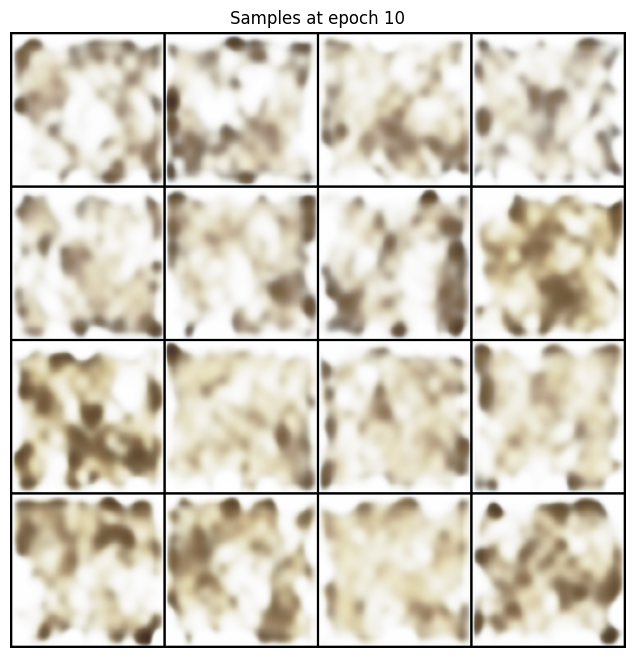

In [ ]:
# Training loop for latent diffusion (score network)
# This loop trains the denoiser model (U-Net) to predict noise in the latent space.
for epoch in range(1, ddpm_epochs + 1):
    torch.cuda.empty_cache()  # Clear GPU memory at the start of each epoch
    gc.collect()  # Run garbage collection to free memory

    train_one_epoch(
        denoiser_model, diffusionmodel, train_loader, optimizer, scaler, vae, device, epoch=epoch
    )
    # Optionally visualize generated samples every 10 epochs
    if epoch % 10 == 0:
        denoiser_model.eval()
        with torch.no_grad():
            # Sample random latent noise for generation
            z_T = torch.randn(16, *latent_shape, device=device)
            z = z_T
            # Reverse diffusion process to generate latents
            for t in reversed(range(diffusionmodel.timesteps)):
                t_batch = torch.full((16,), t, device=device, dtype=torch.long)
                eps_pred = denoiser_model(z, t_batch)
                z = diffusionmodel.step_backward(eps_pred, z, t)
            # Decode generated latents to images
            x_gen = vae.decode(z)
            x_gen = x_gen.cpu().clamp(0, 1)
            # Visualize generated images as a grid
            grid = torchvision.utils.make_grid(x_gen, nrow=4)
            plt.figure(figsize=(8,8)); plt.axis('off'); plt.title(f"Samples at epoch {epoch}")
            plt.imshow(grid.permute(1,2,0).squeeze()); plt.show()

In [ ]:
# Save trained DDPM score network
torch.save(denoiser_model.state_dict(), "latent_ddpm_score_net_butterflies.pth")
print("Latent DDPM score model trained and saved.")

Latent DDPM score model trained and saved.


In [ ]:
# Load the trained DDPM score network weights
denoiser_model.load_state_dict(torch.load("latent_ddpm_score_net_butterflies.pth", map_location=device))
denoiser_model.to(device)
denoiser_model.eval()
print("Latent DDPM score model loaded from file.")

Latent DDPM score model loaded from file.


We may unfreeze the VAE for joint training.

In [ ]:
# Unfreeze VAE parameters for joint training with the diffusion model
for param in vae.parameters():
    param.requires_grad_(True)
# Clear GPU memory before starting joint training
torch.cuda.empty_cache()
gc.collect()
# Create a new optimizer for both VAE and diffusion model parameters
joint_optimizer = torch.optim.AdamW(
    list(vae.parameters()) + list(denoiser_model.parameters()), lr=1e-4
)

joint_epochs = 10  # Number of joint training epochs (adjust as needed)

# Joint training loop: optimize both VAE and diffusion model together
for epoch in range(1, joint_epochs + 1):
    torch.cuda.empty_cache()
    gc.collect()
    vae.train()
    denoiser_model.train()
    total_vae_loss = 0.0
    total_diff_loss = 0.0
    for x in tqdm(train_loader):
        x = x.to(device)
        # Forward pass through VAE
        x_recon, mu, log_var = vae(x)
        vae_elbo = vae_loss(x, x_recon, mu, log_var, recon_loss="lpips")

        # Sample latent z from encoder
        z = reparameterize(mu, log_var)

        # Diffusion loss: forward diffuse z and predict noise
        t = torch.randint(0, diffusionmodel.timesteps, (z.size(0),), device=device)
        z_t, eps_true = diffusionmodel(z, t)
        with torch.amp.autocast('cuda'):
            eps_pred = denoiser_model(z_t, t)
            # Compute per-sample mean squared error
            se = (eps_pred - eps_true).pow(2)                     # [B, C, H, W]
            se_per_sample = se.view(se.size(0), -1).mean(dim=1)  # [B]

            # Compute DDPM weighting for each sample
            beta_t = diffusionmodel.beta[t].to(z.device)
            alpha_bar_t = diffusionmodel.alpha_bar[t].to(z.device)
            w_t = beta_t / (1.0 - alpha_bar_t + 1e-12)

            # Final diffusion loss: weighted MSE
            diff_loss = 0.5 * (w_t * se_per_sample).mean()

        # Total joint loss: VAE ELBO + diffusion loss
        loss = vae_elbo + diff_loss

        joint_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        joint_optimizer.step()

        total_vae_loss += vae_elbo.item()
        total_diff_loss += diff_loss.item()
    avg_vae_loss = total_vae_loss / len(train_loader.dataset)
    avg_diff_loss = total_diff_loss / len(train_loader.dataset)
    print(f"Joint Epoch {epoch}/{joint_epochs} | Avg VAE ELBO: {avg_vae_loss:.4f} | Avg Diff Loss: {avg_diff_loss:.4f}")
    # Optionally visualize samples every 10 epochs
    if epoch % 10 == 0:
        denoiser_model.eval()
        vae.eval()
        with torch.no_grad():
            z_T = torch.randn(16, *latent_shape, device=device)
            z = z_T
            for t in reversed(range(diffusionmodel.timesteps)):
                t_batch = torch.full((16,), t, device=device, dtype=torch.long)
                eps_pred = denoiser_model(z, t_batch)
                z = diffusionmodel.step_backward(eps_pred, z, t)
            x_gen = vae.decode(z)
            x_gen = x_gen.cpu().clamp(0, 1)
            grid = torchvision.utils.make_grid(x_gen, nrow=4)
            plt.figure(figsize=(8,8)); plt.axis('off'); plt.title(f"Joint Samples at epoch {epoch}")
            plt.imshow(grid.permute(1,2,0).squeeze()); plt.show()

100%|██████████| 16/16 [15:20<00:00, 57.54s/it]


Joint Epoch 1/10 | Avg VAE ELBO: 203.1795 | Avg Diff Loss: 0.0001


100%|██████████| 16/16 [14:31<00:00, 54.46s/it]


Joint Epoch 2/10 | Avg VAE ELBO: 98.7052 | Avg Diff Loss: 0.0001


100%|██████████| 16/16 [15:04<00:00, 56.52s/it]


Joint Epoch 3/10 | Avg VAE ELBO: 67.1561 | Avg Diff Loss: 0.0001


  6%|▋         | 1/16 [00:51<12:45, 51.04s/it]

Now, we use DDIM to generate samples from the trained LSGM model.

In [ ]:
# DDIM sampling for latent diffusion (no class conditioning)
# This function generates samples from the trained latent diffusion model using DDIM steps.
@torch.inference_mode()
def generate_ddim(denoiser_model, taus, backward_sampler, size, device):
    # Start from pure Gaussian noise in the latent space
    xnoisy = torch.randn(size, device=device)
    # Set the model in evaluation mode for inference
    denoiser_model.eval()
    # Initialize time step variables for DDIM update
    last_t = torch.ones(size[0], dtype=torch.long, device=device) * (backward_sampler.timesteps-1)
    alpha_bar_t = get_from_idx(backward_sampler.alpha_bar, last_t)
    sqrt_alpha_bar_t = get_from_idx(backward_sampler.sqrt_alpha_bar, last_t)
    sqrt_one_minus_alpha_bar_t = get_from_idx(backward_sampler.sqrt_one_minus_alpha_bar, last_t)
    # Reverse the diffusion process using DDIM steps
    for t in tqdm(iterable=reversed(taus),
                  dynamic_ncols=False,total=len(taus),
                  desc="Sampling :: ", position=0):
        # Prepare time step tensor for the batch
        ts = torch.ones(size[0], dtype=torch.long, device=device) * t
        # Predict noise at current step
        predicted_noise = denoiser_model(xnoisy, ts)
        # Get DDIM update coefficients for current step
        alpha_bar_t_prev = get_from_idx(backward_sampler.alpha_bar, ts)
        sqrt_alpha_bar_t_prev = get_from_idx(backward_sampler.sqrt_alpha_bar, ts)
        sqrt_one_minus_alpha_bar_t_prev = get_from_idx(backward_sampler.sqrt_one_minus_alpha_bar, ts)
        # Estimate the original latent (x0) from noisy latent and predicted noise
        predicted_x0 = (xnoisy - sqrt_one_minus_alpha_bar_t * predicted_noise) / sqrt_alpha_bar_t
        # DDIM update: combine predicted x0 and noise for next step
        xnoisy = sqrt_alpha_bar_t_prev * predicted_x0 + sqrt_one_minus_alpha_bar_t_prev * predicted_noise
        # Update coefficients for next iteration
        alpha_bar_t = alpha_bar_t_prev
        sqrt_alpha_bar_t = sqrt_alpha_bar_t_prev
        sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar_t_prev
    return xnoisy

# Example usage for latent diffusion:
# Set DDIM step size and create time steps
ddim_stepsize = 10
taus = np.arange(0, diffusionmodel.timesteps, ddim_stepsize)
# Generate latent samples using DDIM
z_latents = generate_ddim(denoiser_model, taus, diffusionmodel, (16, *latent_shape), device)
# Decode latents to images with the VAE
x_gen = vae.decode(z_latents)
x_gen = x_gen.cpu().clamp(0, 1)
# Visualize generated samples as a grid
grid = torchvision.utils.make_grid(x_gen, nrow=4)
plt.figure(figsize=(8,8)); plt.axis('off'); plt.title("DDIM Latent Diffusion Samples")
plt.imshow(grid.permute(1,2,0).squeeze()); plt.show()